In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/Kai-White/COMP-SCI-5530-HW2/refs/heads/main/Raw%20Data/diabetes.csv")

In [2]:
import random
random.seed(100)
sample_df=df.sample(n=25, replace=True, weights=None, random_state=None, axis=None, ignore_index=False)
sample_df



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
589,0,73,0,0,0,21.1,0.342,25,0
521,3,124,80,33,130,33.2,0.305,26,0
461,1,71,62,0,0,21.8,0.416,26,0
433,2,139,75,0,0,25.6,0.167,29,0
45,0,180,66,39,0,42.0,1.893,25,1
120,0,162,76,56,100,53.2,0.759,25,1
73,4,129,86,20,270,35.1,0.231,23,0
520,2,68,70,32,66,25.0,0.187,25,0
49,7,105,0,0,0,0.0,0.305,24,0
393,4,116,72,12,87,22.1,0.463,37,0


In [3]:
sample_df["Glucose"].mean()


np.float64(125.4)

In [4]:
sample_df["Glucose"].max()

198

In [5]:
df["Glucose"].mean()


np.float64(120.89453125)

In [6]:
df["Glucose"].max()

199

<Axes: title={'center': 'Sample and Population Glucose Levels'}>

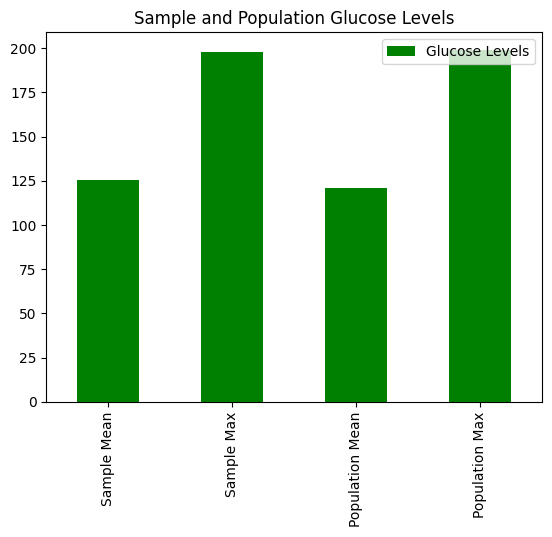

In [7]:
glucose_df = pd.DataFrame({'Glucose Levels': [sample_df["Glucose"].mean(), sample_df["Glucose"].max(), df["Glucose"].mean(),df["Glucose"].max()]}, index=['Sample Mean', 'Sample Max', 'Population Mean', 'Population Max'])

glucose_df.plot.bar(title='Sample and Population Glucose Levels', color='green')

<Axes: title={'center': 'Sample and Population 98th Percentile BMI'}>

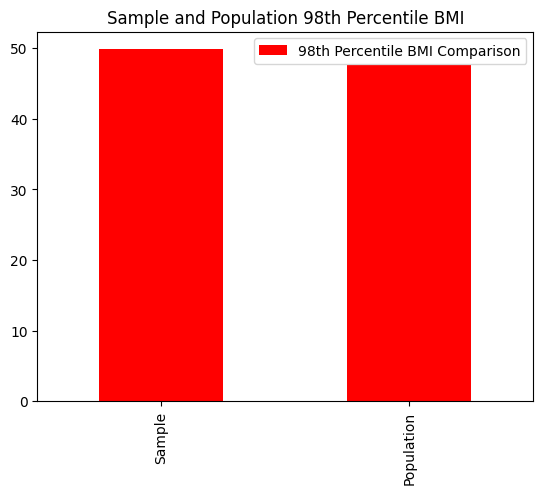

In [8]:
df_BMI = pd.DataFrame({'98th Percentile BMI Comparison': [sample_df["BMI"].quantile(q=0.98),df["BMI"].quantile(q=0.98)]}, index=['Sample', 'Population'])

df_BMI.plot.bar(title='Sample and Population 98th Percentile BMI', color='red')

In [9]:
df["BloodPressure"].describe()


,BloodPressure
count,768.000000
mean,69.105469
std,19.355807
min,0.000000
25%,62.000000
50%,72.000000
75%,80.000000
max,122.000000


In [11]:
import numpy as np
bootstrapped_BP = np.array([np.random.choice(df["BloodPressure"], 150, replace = True) for _ in range(500)])
Mean = np.mean(bootstrapped_BP)
StDev = np.std(bootstrapped_BP)
Min = np.min(bootstrapped_BP)
L_Quartile = np.quantile(bootstrapped_BP, 0.25)
Median = np.quantile(bootstrapped_BP, 0.5)
U_Quartile = np.quantile(bootstrapped_BP, 0.75)
Max = np.max(bootstrapped_BP)

print(Mean, StDev, Min, L_Quartile, Median, U_Quartile, Max)


69.04274666666667 19.349704891526265 0 62.0 72.0 80.0 122


In [12]:
comparison_df = pd.DataFrame({
    'Original Data': [df["BloodPressure"].mean(), df["BloodPressure"].std(), df["BloodPressure"].min(), df["BloodPressure"].quantile(0.25), df["BloodPressure"].quantile(0.5), df["BloodPressure"].quantile(0.75), df["BloodPressure"].max()],
    'Bootstrapped Data': [Mean, StDev, Min, L_Quartile, Median, U_Quartile, Max]
}, index=['Mean', 'Standard Deviation', 'Min', 'Lower Quartile (25%)', 'Median (50%)', 'Upper Quartile (75%)', 'Max'])

print(comparison_df)

                      Original Data  Bootstrapped Data
Mean                      69.105469          69.042747
Standard Deviation        19.355807          19.349705
Min                        0.000000           0.000000
Lower Quartile (25%)      62.000000          62.000000
Median (50%)              72.000000          72.000000
Upper Quartile (75%)      80.000000          80.000000
Max                      122.000000         122.000000


The bootstrapped version maintained accuracy to the original data frame. The mean and standard deviations were virtually the same. The minimum and maximum turned out to be the same, which makes sense if we are taking 500 samples of size 150 from the original dataset which had around 750 records.

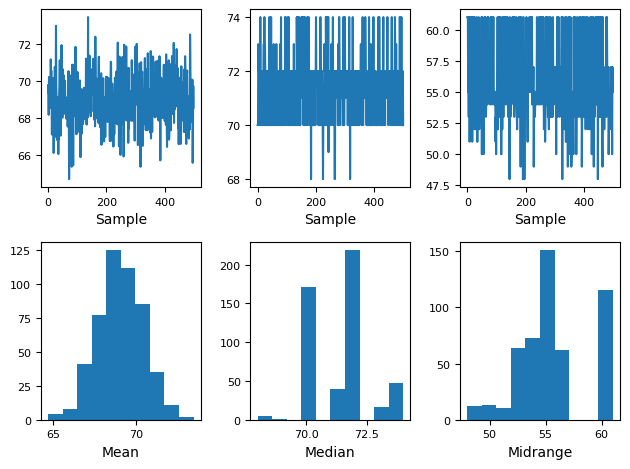

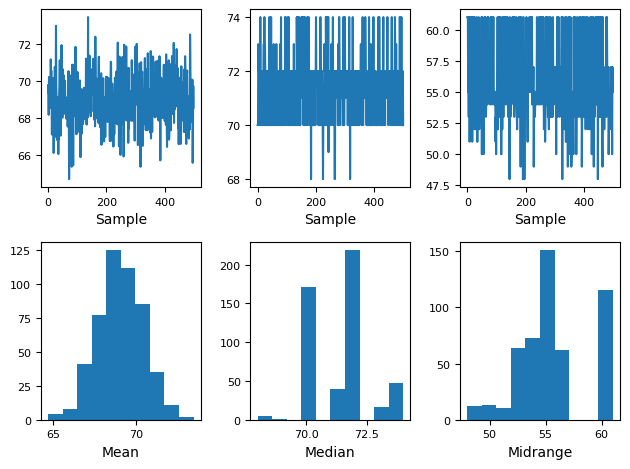

In [10]:
pd.plotting.bootstrap_plot(df["BloodPressure"], size=150, samples=500)